In [1]:
import pandas as pd
import re
import numpy as np
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Indian Liver Patient Dataset (ILPD).csv", header=None)

In [3]:
df.columns = [
    'Age',
    'Gender',
    'Total_Bilirubin',
    'Direct_Bilirubin',
    'Alkaline_Phosphotase',
    'Alamine_Aminotransferase',
    'Aspartate_Aminotransferase',
    'Total_Proteins',
    'Albumin',
    'Albumin_and_Globulin_Ratio',
    'Target'
]

In [4]:
df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [5]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [6]:
df.shape

(583, 11)

In [7]:
df.dtypes

,0
Age,int64
Gender,object
Total_Bilirubin,float64
Direct_Bilirubin,float64
Alkaline_Phosphotase,int64
Alamine_Aminotransferase,int64
Aspartate_Aminotransferase,int64
Total_Proteins,float64
Albumin,float64
Albumin_and_Globulin_Ratio,float64


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Proteins              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [9]:
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [10]:
# Melihat Nilai Kosong
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Proteins,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [11]:
# print(df.isnull().sum())

In [12]:
df.isnull()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
578,False,False,False,False,False,False,False,False,False,False,False
579,False,False,False,False,False,False,False,False,False,False,False
580,False,False,False,False,False,False,False,False,False,False,False
581,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.duplicated().sum()

np.int64(13)

In [14]:
df=df.drop_duplicates()

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# print(df['Gender'].unique())

# df.loc[:, 'Gender'] = df['Gender'].map({
#     'Female': 0,
#     'Male': 1
# })

# print(df['Gender'].value_counts())

In [17]:
from sklearn.preprocessing import LabelEncoder

# Ubah kolom gender: Female -> 0, Male -> 1
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

/tmp/ipykernel_13627/110514277.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})


In [18]:
df['Target'] = df['Target'].map({
    1: 1,
    2: 0
})

/tmp/ipykernel_13627/2873370848.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Target'] = df['Target'].map({


In [19]:
print(df['Target'])

0      1
1      1
2      1
3      1
4      1
      ..
578    0
579    1
580    1
581    1
582    0
Name: Target, Length: 570, dtype: int64


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         570 non-null    int64  
 1   Gender                      570 non-null    int64  
 2   Total_Bilirubin             570 non-null    float64
 3   Direct_Bilirubin            570 non-null    float64
 4   Alkaline_Phosphotase        570 non-null    int64  
 5   Alamine_Aminotransferase    570 non-null    int64  
 6   Aspartate_Aminotransferase  570 non-null    int64  
 7   Total_Proteins              570 non-null    float64
 8   Albumin                     570 non-null    float64
 9   Albumin_and_Globulin_Ratio  566 non-null    float64
 10  Target                      570 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 53.4 KB


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [23]:
df

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [24]:
import warnings
warnings.filterwarnings('ignore')

<Axes: ylabel='count'>

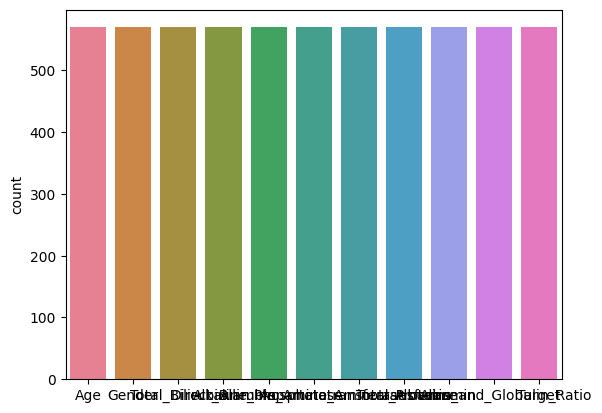

In [25]:
sns.countplot(data=df)

In [26]:
# df.hist(bins=10,figsize=(10,10))
# plt.show()

<Axes: xlabel='Target'>

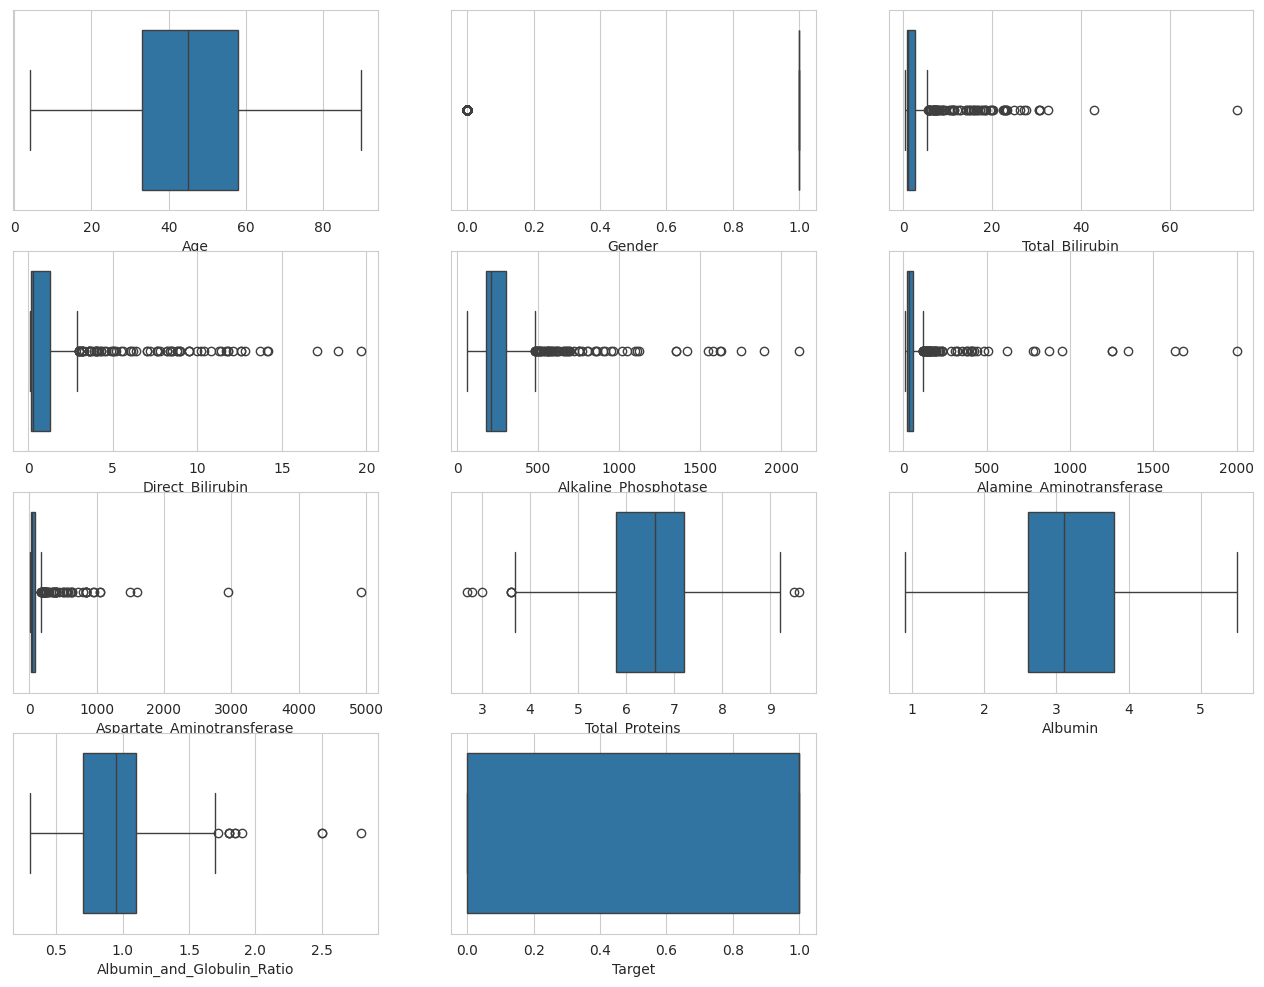

In [27]:
#Box Plot
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(4,3,1)
sns.boxplot(x='Age',data=df)
plt.subplot(4,3,2)
sns.boxplot(x='Gender',data=df)
plt.subplot(4,3,3)
sns.boxplot(x='Total_Bilirubin',data=df)
plt.subplot(4,3,4)
sns.boxplot(x='Direct_Bilirubin',data=df)
plt.subplot(4,3,5)
sns.boxplot(x='Alkaline_Phosphotase',data=df)
plt.subplot(4,3,6)
sns.boxplot(x='Alamine_Aminotransferase',data=df)
plt.subplot(4,3,7)
sns.boxplot(x='Aspartate_Aminotransferase',data=df)
plt.subplot(4,3,8)
sns.boxplot(x='Total_Proteins',data=df)
plt.subplot(4,3,9)
sns.boxplot(x='Albumin',data=df)
plt.subplot(4,3,10)
sns.boxplot(x='Albumin_and_Globulin_Ratio',data=df)
plt.subplot(4,3,11)
sns.boxplot(x='Target',data=df)

In [28]:
# empty_string_rows = df[df['Albumin_and_Globulin_Ratio'] == '']
# print(empty_string_rows)

In [29]:
#jika 1 kolom
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(df['Albumin_and_Globulin_Ratio'].mean())

In [30]:
# print(df['Albumin_and_Globulin_Ratio'])

In [31]:
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Proteins,0
Albumin,0
Albumin_and_Globulin_Ratio,0


In [32]:
df.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Albumin_and_Globulin_Ratio,Target
count,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000,570.000000
mean,44.849123,0.754386,3.321754,1.497544,291.750877,79.728070,109.380702,6.496316,3.148947,0.948004,0.712281
std,16.242182,0.430829,6.267941,2.833231,245.291859,181.471697,290.880671,1.088300,0.796813,0.318510,0.453097
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,1.000000,0.800000,0.200000,176.000000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,41.000000,6.600000,3.100000,0.948004,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.000000,86.750000,7.200000,3.800000,1.100000,1.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


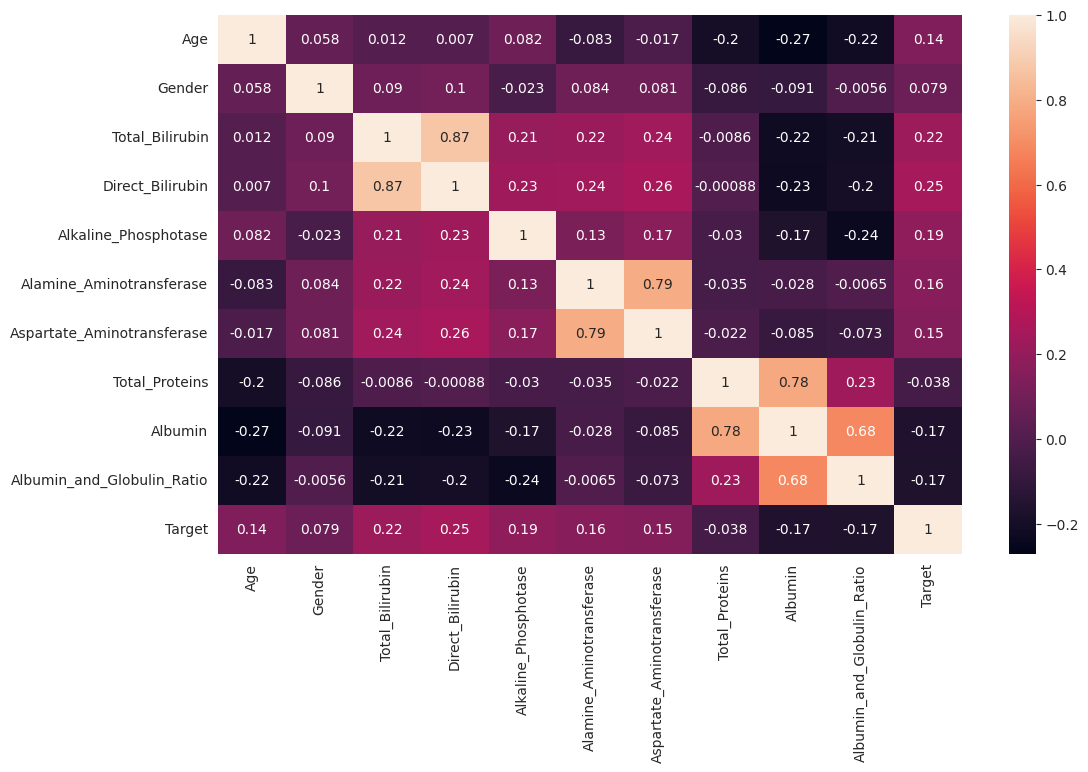

In [33]:
# hitung korelasi
corrmat = df.corr()

# tampilkan heatmap
plt.figure(figsize=(12, 7))
sns.heatmap(corrmat, annot=True)
plt.show()

In [34]:
df_selected=df.drop(['Age','Gender','Alkaline_Phosphotase','Albumin_and_Globulin_Ratio'],axis='columns')

In [35]:
from sklearn.preprocessing import QuantileTransformer
x=df_selected
quantile  = QuantileTransformer()
X = quantile.fit_transform(x)
df_new=quantile.transform(X)
df_new=pd.DataFrame(X)
df_new.columns =['Total_Bilirubin', 'Direct_Bilirubin','Alamine_Aminotransferase','Aspartate_Aminotransferase','Total_Proteins','Albumin','Target']
df_new.head()

,Total_Bilirubin,Direct_Bilirubin,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin,Target
0,0.154657,0.000000,0.079965,0.089631,0.570299,0.580844,1.0
1,0.918278,0.920914,0.772408,0.790861,0.831283,0.539543,1.0
2,0.891916,0.901582,0.745167,0.691564,0.666081,0.580844,1.0
3,0.500000,0.548330,0.042179,0.129174,0.570299,0.616872,1.0
4,0.826011,0.824253,0.350615,0.651142,0.783831,0.180141,1.0


In [36]:
# from sklearn.preprocessing import QuantileTransformer
# import pandas as pd

# # Pisahkan fitur dan target
# X = df_selected.drop('Target', axis=1)
# y = df_selected['Target']

# # Quantile hanya untuk fitur
# quantile = QuantileTransformer(random_state=42)

# X_quantile = quantile.fit_transform(X)

# X = pd.DataFrame(
#     X_quantile,
#     columns=X.columns
# )

<Axes: xlabel='Albumin'>

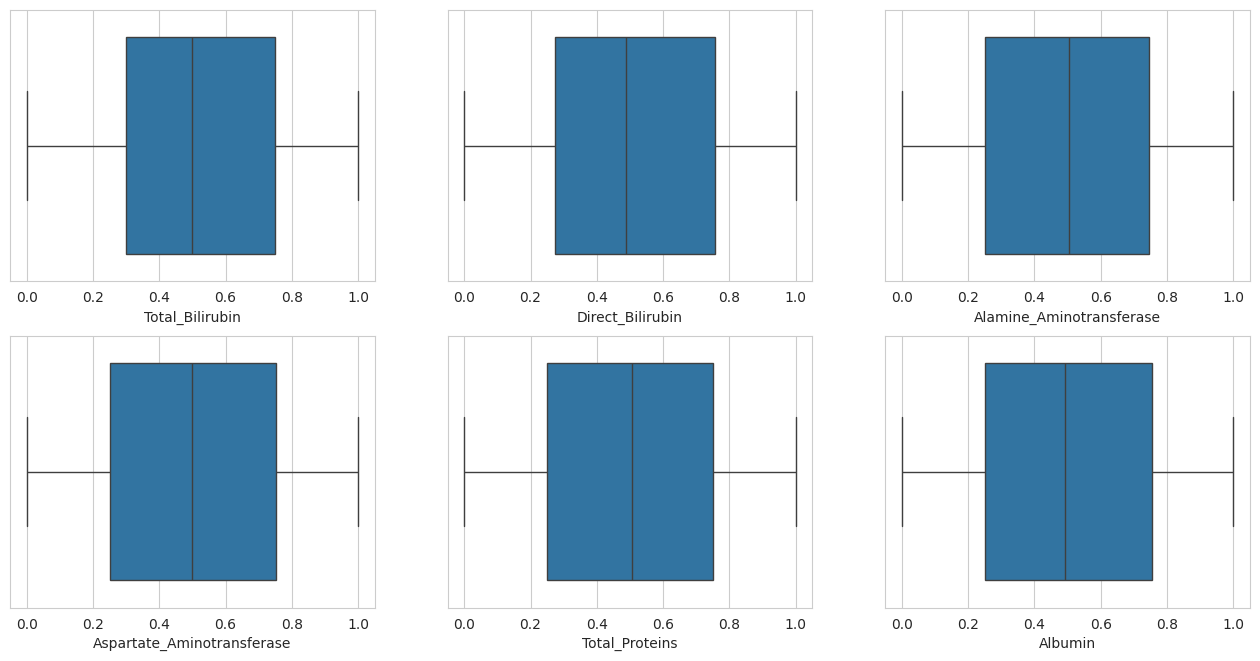

In [37]:
plt.figure(figsize=(16,12))
sns.set_style(style='whitegrid')
plt.subplot(3,3,1)
sns.boxplot(x=df_new['Total_Bilirubin'],data=df_new)
plt.subplot(3,3,2)
sns.boxplot(x=df_new['Direct_Bilirubin'],data=df_new)
plt.subplot(3,3,3)
sns.boxplot(x=df_new['Alamine_Aminotransferase'],data=df_new)
plt.subplot(3,3,4)
sns.boxplot(x=df_new['Aspartate_Aminotransferase'],data=df_new)
plt.subplot(3,3,5)
sns.boxplot(x=df_new['Total_Proteins'],data=df_new)
plt.subplot(3,3,6)
sns.boxplot(x=df_new['Albumin'],data=df_new)

In [38]:
target_name='Target'
y= df_new[target_name] #given predictions - training data
X=df_new.drop(target_name,axis=1) #dropping kolom Outcome & simpan kolom lainnya menjadi X

In [39]:
X.head() # contains only independent features

,Total_Bilirubin,Direct_Bilirubin,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin
0,0.154657,0.000000,0.079965,0.089631,0.570299,0.580844
1,0.918278,0.920914,0.772408,0.790861,0.831283,0.539543
2,0.891916,0.901582,0.745167,0.691564,0.666081,0.580844
3,0.500000,0.548330,0.042179,0.129174,0.570299,0.616872
4,0.826011,0.824253,0.350615,0.651142,0.783831,0.180141


In [40]:
y.head() #contains dependent feature

,Target
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0) #splitting data in 80% train, 20%test

In [42]:
X_train.shape,y_train.shape

((456, 6), (456,))

In [43]:
X_test.shape,y_test.shape

((114, 6), (114,))

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=0) #splitting data in 80% train, 20%test
X_train

,Total_Bilirubin,Direct_Bilirubin,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin
337,0.667838,0.665202,0.760984,0.639719,0.231107,0.365554
170,0.685413,0.665202,0.520211,0.524605,0.013181,0.007030
339,0.154657,0.274165,0.520211,0.398946,0.959578,0.937610
517,0.539543,0.486819,0.042179,0.153779,0.666081,0.753954
408,0.500000,0.486819,0.653779,0.702988,0.712654,0.723199
...,...,...,...,...,...,...
277,0.500000,0.486819,0.653779,0.536028,0.988576,0.937610
9,0.154657,0.274165,0.699473,0.639719,0.570299,0.616872
359,0.154657,0.274165,0.398067,0.075571,0.991213,1.000000
192,0.744288,0.739016,0.373462,0.177504,0.853251,0.844464


In [45]:
y_train

,Target
337,1.0
170,0.0
339,1.0
517,0.0
408,0.0
...,...
277,1.0
9,1.0
359,1.0
192,1.0


In [46]:
X_test

,Total_Bilirubin,Direct_Bilirubin,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Proteins,Albumin
196,0.426186,0.486819,0.249561,0.398946,0.506151,0.789982
261,0.667838,0.665202,0.303163,0.177504,0.924429,0.844464
132,0.048330,0.000000,0.160808,0.153779,0.388401,0.580844
468,0.730228,0.757469,0.891037,0.943761,0.783831,0.844464
37,0.739016,0.724956,0.480668,0.577329,0.095782,0.252197
...,...,...,...,...,...,...
519,0.154657,0.274165,0.018453,0.075571,0.959578,0.539543
264,0.698594,0.665202,0.622144,0.481547,0.310193,0.324253
365,0.154657,0.000000,0.160808,0.498243,0.783831,0.580844
407,0.918278,0.917399,0.653779,0.628295,0.449033,0.155536


In [47]:
y_test

,Target
196,1.0
261,1.0
132,0.0
468,1.0
37,1.0
...,...
519,0.0
264,1.0
365,1.0
407,1.0


Fitting 4 folds for each of 18 candidates, totalling 72 fits
Classification Report is:
               precision    recall  f1-score   support

         0.0       0.67      0.11      0.18        38
         1.0       0.69      0.97      0.80        76

    accuracy                           0.68       114
   macro avg       0.68      0.54      0.49       114
weighted avg       0.68      0.68      0.60       114


 F1:
 0.8043478260869565

 Precision score is:
 0.6851851851851852

 Recall score is:
 0.9736842105263158


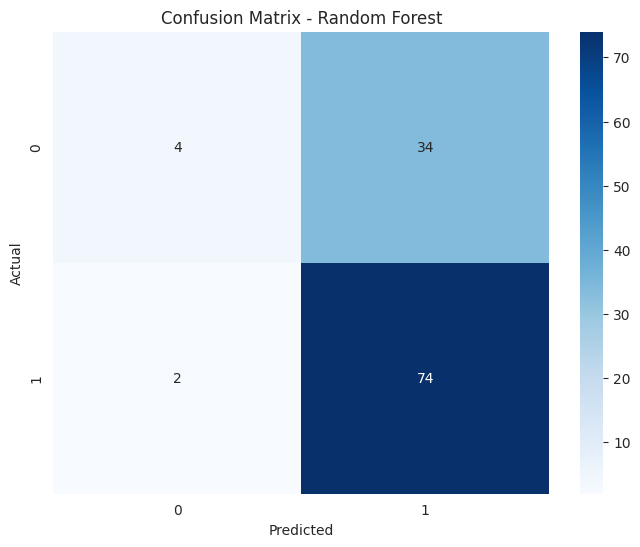

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score

rf = RandomForestClassifier(random_state=42)

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=params,
    cv=4,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

best_model = grid_search.fit(X_train, y_train)

rf_pred = best_model.predict(X_test)

print("Classification Report is:\n", classification_report(y_test, rf_pred))
print("\n F1:\n", f1_score(y_test, rf_pred))
print("\n Precision score is:\n", precision_score(y_test, rf_pred))
print("\n Recall score is:\n", recall_score(y_test, rf_pred))

cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 4 folds for each of 8 candidates, totalling 32 fits
Classification Report is:
               precision    recall  f1-score   support

         0.0       0.67      0.05      0.10        38
         1.0       0.68      0.99      0.80        76

    accuracy                           0.68       114
   macro avg       0.67      0.52      0.45       114
weighted avg       0.67      0.68      0.57       114


 F1:
 0.8021390374331551

 Precision score is:
 0.6756756756756757

 Recall score is:
 0.9868421052631579


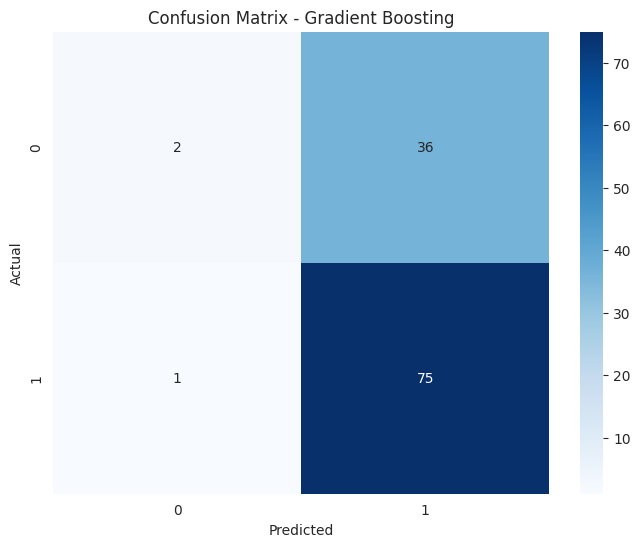

In [49]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score

gb = GradientBoostingClassifier()

params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=params,
    cv=4,
    n_jobs=-1,
    verbose=1,
    scoring="accuracy"
)

best_model = grid_search.fit(X_train, y_train)

gb_pred = best_model.predict(X_test)

print("Classification Report is:\n", classification_report(y_test, gb_pred))
print("\n F1:\n", f1_score(y_test, gb_pred))
print("\n Precision score is:\n", precision_score(y_test, gb_pred))
print("\n Recall score is:\n", recall_score(y_test, gb_pred))

cm = confusion_matrix(y_test, gb_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Gradient Boosting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 4 folds for each of 3 candidates, totalling 12 fits
Classification Report:
               precision    recall  f1-score   support

         0.0       0.57      0.79      0.66        38
         1.0       0.87      0.70      0.77        76

    accuracy                           0.73       114
   macro avg       0.72      0.74      0.72       114
weighted avg       0.77      0.73      0.74       114


F1: 0.7737226277372263
Precision: 0.8688524590163934
Recall: 0.6973684210526315


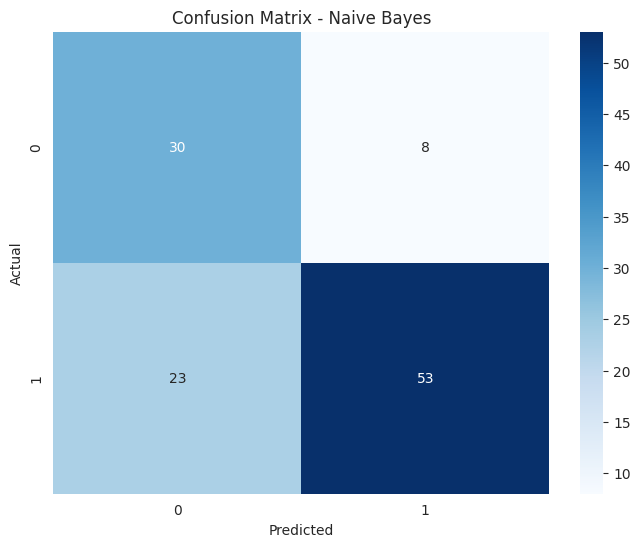

In [50]:
# =========================
# MODEL: NAIVE BAYES
# =========================
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score

nb = GaussianNB()

params = {
    'var_smoothing': [1e-9, 1e-8, 1e-7]
}

grid_search = GridSearchCV(
    estimator=nb,
    param_grid=params,
    cv=4,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

best_model = grid_search.fit(X_train, y_train)

nb_pred = best_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, nb_pred))
print("\nF1:", f1_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))

cm = confusion_matrix(y_test, nb_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Fitting 4 folds for each of 18 candidates, totalling 72 fits
Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.16      0.26        38
         1.0       0.70      0.97      0.81        76

    accuracy                           0.70       114
   macro avg       0.72      0.57      0.54       114
weighted avg       0.72      0.70      0.63       114


F1: 0.8131868131868132
Precision: 0.6981132075471698
Recall: 0.9736842105263158


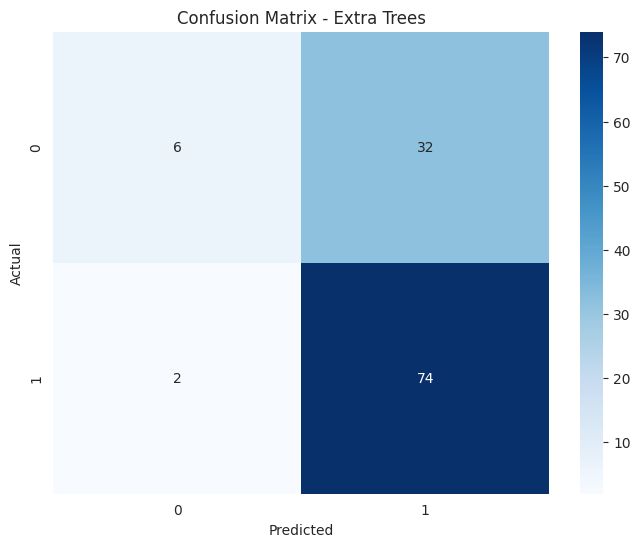

In [51]:
# =========================
# MODEL: EXTRA TREES
# =========================
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score

et = ExtraTreesClassifier(random_state=42)

params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=et,
    param_grid=params,
    cv=4,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy'
)

best_model = grid_search.fit(X_train, y_train)

et_pred = best_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, et_pred))
print("\nF1:", f1_score(y_test, et_pred))
print("Precision:", precision_score(y_test, et_pred))
print("Recall:", recall_score(y_test, et_pred))

cm = confusion_matrix(y_test, et_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Extra Trees")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV

In [53]:
#List Hyperparameters to tune
knn= KNeighborsClassifier()
n_neighbors = list(range(15,25))
p=[1,2]
weights = ['uniform', 'distance']
metric = ['euclidean', 'manhattan', 'minkowski']

#convert to dictionary
hyperparameters = dict(n_neighbors=n_neighbors, p=p,weights=weights,metric=metric)

#Making model
cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
grid_search = GridSearchCV(estimator=knn, param_grid=hyperparameters, n_jobs=-1, cv=cv, scoring='f1',error_score=0)

In [54]:
best_model = grid_search.fit(X_train,y_train)

In [55]:
#Best Hyperparameters Value
print('Best leaf_size:', best_model.best_estimator_.get_params()['leaf_size'])
print('Best p:', best_model.best_estimator_.get_params()['p'])
print('Best n_neighbors:', best_model.best_estimator_.get_params()['n_neighbors'])

Best leaf_size: 30
Best p: 1
Best n_neighbors: 19


In [56]:
#Predict testing set
knn_pred = best_model.predict(X_test)

Classification Report is:
               precision    recall  f1-score   support

         0.0       0.52      0.29      0.37        38
         1.0       0.71      0.87      0.78        76

    accuracy                           0.68       114
   macro avg       0.62      0.58      0.58       114
weighted avg       0.65      0.68      0.65       114


 F1:
 0.7810650887573964

 Precision score is:
 0.7096774193548387

 Recall score is:
 0.868421052631579

 Confusion Matrix:



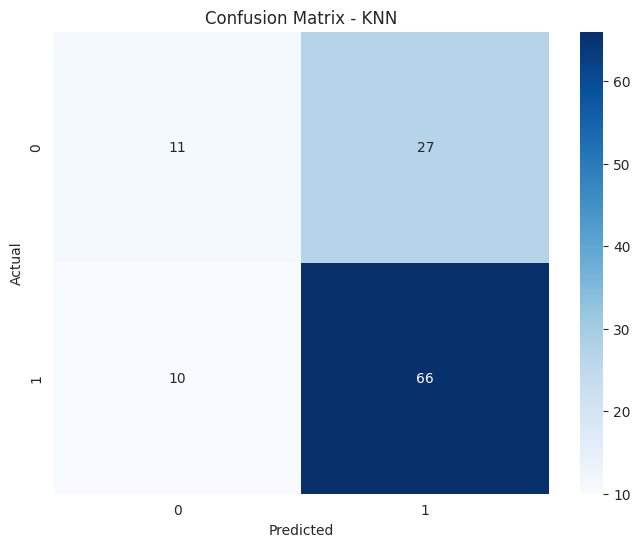

In [57]:
print("Classification Report is:\n",classification_report(y_test,knn_pred))
print("\n F1:\n",f1_score(y_test,knn_pred))
print("\n Precision score is:\n",precision_score(y_test,knn_pred))
print("\n Recall score is:\n",recall_score(y_test,knn_pred))
print("\n Confusion Matrix:\n")
# Confusion Matrix
cm = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [64]:
from sklearn.metrics import accuracy_score
import pandas as pd

results = []

def add_result(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    results.append([name, acc])

# =========================
# MASUKKAN SEMUA MODEL
# =========================
add_result("Random Forest", y_test, rf_pred)
add_result("Gradient Boosting", y_test, gb_pred)
add_result("Naive Bayes", y_test, nb_pred)
add_result("Extra Trees", y_test, et_pred)
add_result("KNN", y_test, knn_pred)

# =========================
# TABEL HASIL
# =========================
df_result = pd.DataFrame(results, columns=["Model", "Accuracy"])

# urutkan dari terbaik
df_result = df_result.sort_values(by="Accuracy", ascending=False)

df_result

,Model,Accuracy
2,Naive Bayes,0.728070
3,Extra Trees,0.701754
0,Random Forest,0.684211
1,Gradient Boosting,0.675439
4,KNN,0.675439


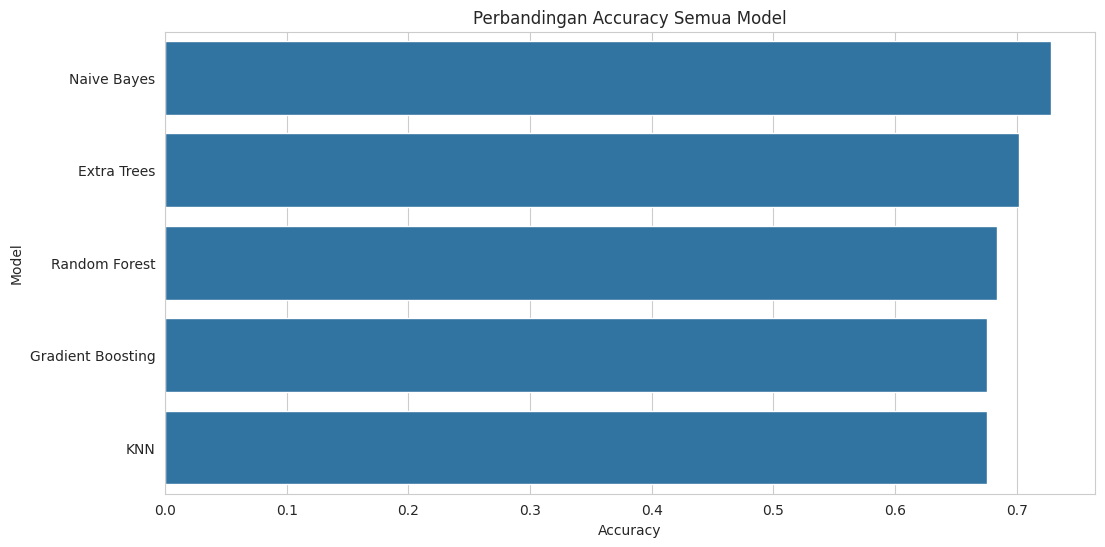

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=df_result, x="Accuracy", y="Model")
plt.title("Perbandingan Accuracy Semua Model")
plt.show()

In [66]:
best_model_name = df_result.iloc[0]["Model"]

print("Model Terbaik Berdasarkan Accuracy:")
print(best_model_name)
print("Accuracy:", df_result.iloc[0]["Accuracy"])

Model Terbaik Berdasarkan Accuracy:
Naive Bayes
Accuracy: 0.7280701754385965


In [68]:
import joblib

model_dict = {
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred,
    "Naive Bayes": nb_pred,
    "Extra Trees": et_pred,
    "KNN": knn_pred
}

final_model = model_dict[best_model_name]

joblib.dump(final_model, "ilpd_best_model.pkl")
joblib.dump(quantile, "quantile_transformer.pkl")

print("Model terbaik disimpan:", best_model_name)

Model terbaik disimpan: Naive Bayes


In [62]:
# #menyimpan model mesin learning yang sudah kita buat

# import pickle
# import joblib

# joblib.dump(knn_pred, "ilpd_knn_pred.pkl")
# joblib.dump(quantile, "quantile_transformer.pkl")